Zomato Restaurant Data Analysis & Visualization

Portfolio project focused on understanding restaurant categories, ratings, pricing, online ordering, customer engagement, and relationships between key numerical variables.

Project questions

1. Which restaurant types are most common in the dataset?
2. How are restaurant ratings distributed?
3. How does cost vary across restaurant types?
4. Is restaurant cost associated with restaurant rating?
5. How common is online ordering?
6. Which restaurants receive the most customer votes?
7. What relationships exist between rating, votes, and cost?

Dataset scope

The dataset contains 148 restaurant records. All findings in this notebook describe this dataset and should not be generalized to the entire Zomato restaurant market.

Import Libraries

In [16]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set_theme(style="whitegrid")

Load Dataset

In [17]:
df = pd.read_csv("Zomato-data-.csv")

df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


Dataset Overview

In [18]:
df.head(10)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet


In [19]:
print("Shape:", df.shape)


Shape: (148, 7)


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [46]:
df.describe()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,148,145,San Churro Cafe,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_order,148,2,No,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
book_table,148,2,No,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rate,148.0,NaN,NaN,NaN,3.633108,0.402271,2.6,3.3,3.7,3.9,4.6
votes,148.0,NaN,NaN,NaN,264.810811,653.676951,0.0,6.75,43.5,221.75,4884.0
cost_for_two,148.0,NaN,NaN,NaN,418.243243,223.085098,100.0,200.0,400.0,600.0,950.0
type_of_restaurant,148,4,Dining,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleaning & Preparation

The `rate` column contains values such as `4.1/5`. The numerical rating is extracted for analysis.

The original column names are also simplified to make them easier to work with in Python.

In [22]:
df['rate'] = df['rate'].str.split('/').str[0].str.strip().astype(float)

df.rename(
    columns={
        'approx_cost(for two people)': 'cost_for_two',
        'listed_in(type)': 'type_of_restaurant'
    },
    inplace=True
)

df.head()


,name,online_order,book_table,rate,votes,cost_for_two,type_of_restaurant
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                148 non-null    object 
 1   online_order        148 non-null    object 
 2   book_table          148 non-null    object 
 3   rate                148 non-null    float64
 4   votes               148 non-null    int64  
 5   cost_for_two        148 non-null    int64  
 6   type_of_restaurant  148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Check Missing Values

In [24]:
df.isna().sum()


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
cost_for_two,0
type_of_restaurant,0


Quick Value-Count Function

This reusable function summarizes the number of unique values and the 10 most frequent values in each column.

In [25]:
def value_counts_all(df):
    for column in df.columns:
        print(f"\n==== {column} ====")
        print("Unique values:", df[column].nunique())
        print(df[column].value_counts().head(10))

value_counts_all(df)



==== name ====
Unique values: 145
name
San Churro Cafe                                    2
Onesta                                             2
CAFE NOVA                                          2
Addhuri Udupi Bhojana                              1
Jalsa                                              1
Grand Village                                      1
Timepass Dinner                                    1
Rosewood International Hotel - Bar & Restaurant    1
Spice Elephant                                     1
Smacznego                                          1
Name: count, dtype: int64

==== online_order ====
Unique values: 2
online_order
No     90
Yes    58
Name: count, dtype: int64

==== book_table ====
Unique values: 2
book_table
No     140
Yes      8
Name: count, dtype: int64

==== rate ====
Unique values: 19
rate
3.8    20
3.7    15
3.3    14
3.4    12
4.1    11
3.6    11
4.0    10
3.9    10
4.2     8
3.2     7
Name: count, dtype: int64

==== votes ====
Unique values: 90
votes


Duplicate Records vs Repeated Restaurant Names

A completely duplicated row and a repeated restaurant name are different data-quality situations.

A restaurant name can appear more than once because the same restaurant may be associated with different restaurant-type categories in the dataset.

In [26]:
print("Completely duplicated rows:", df.duplicated().sum())
print("Repeated restaurant names:", df['name'].duplicated().sum())


Completely duplicated rows: 0
Repeated restaurant names: 3


In [27]:
repeated_names = (
    df[df['name'].duplicated(keep=False)]
    .sort_values('name')
)

repeated_names


,name,online_order,book_table,rate,votes,cost_for_two,type_of_restaurant
25,CAFE NOVA,No,No,3.2,11,600,Cafes
104,CAFE NOVA,No,No,3.2,11,600,Dining
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
44,Onesta,Yes,Yes,4.6,2556,600,other
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
14,San Churro Cafe,Yes,No,3.8,918,800,Cafes


Why this matters

For the Top 10 restaurants by votes analysis, we want one value per restaurant name. Repeated names are therefore aggregated instead of being treated as separate restaurants.

`max()` is used because the repeated rows for the same restaurant contain the same vote count in this dataset. Summing them would incorrectly inflate customer votes.

Exploratory Data Analysis

Restaurant Type Distribution — Matplotlib

Matplotlib provides a straightforward static view of the distribution of restaurant categories.

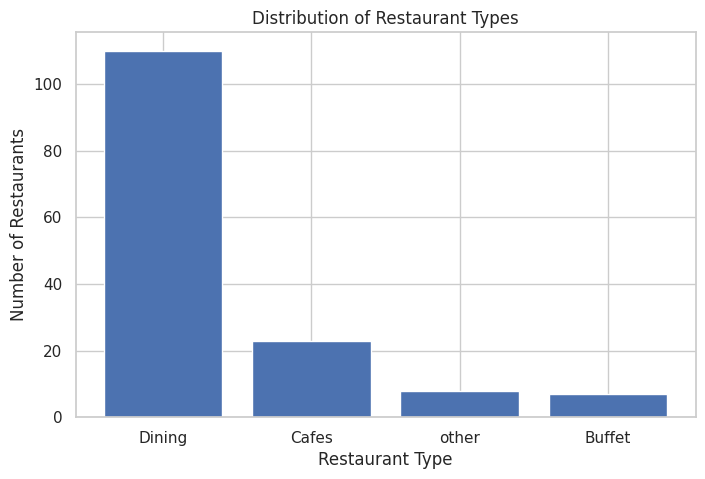

In [28]:
restaurant_type_counts = df['type_of_restaurant'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(restaurant_type_counts.index, restaurant_type_counts.values)

plt.title('Distribution of Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)

plt.show()


Restaurant Type Distribution — Seaborn

The same distribution is visualized with Seaborn to demonstrate a statistical visualization workflow.

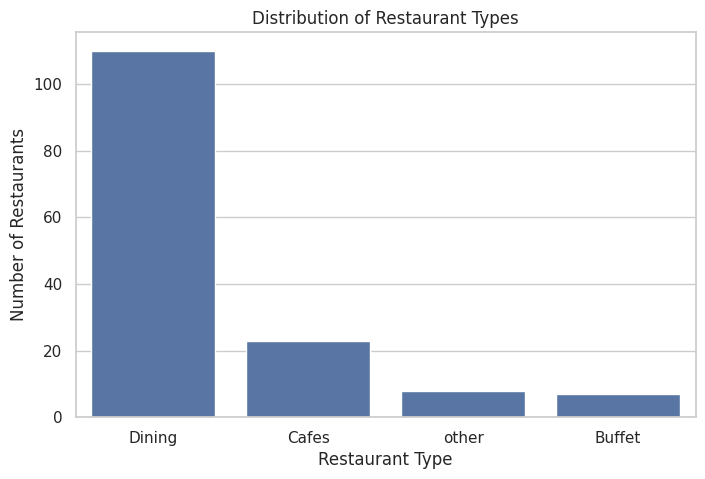

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='type_of_restaurant',
    order=df['type_of_restaurant'].value_counts().index
)

plt.title('Distribution of Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants')

plt.show()


Restaurant Type Distribution — Plotly

Plotly provides an interactive version of the restaurant-type distribution with hover information.

In [30]:
type_counts = (
    df['type_of_restaurant']
    .value_counts()
    .rename_axis('restaurant_type')
    .reset_index(name='count')
)

fig = px.bar(
    type_counts,
    x='restaurant_type',
    y='count',
    text='count',
    title='Restaurant Type Distribution',
    labels={
        'restaurant_type': 'Restaurant Type',
        'count': 'Number of Restaurants'
    }
)

fig.show()

Insight

Dining is the dominant restaurant category in this dataset, followed by Cafes. The `other` and Buffet categories have substantially fewer observations.

This describes the composition of the provided sample, not the overall Zomato restaurant market.

Rating Distribution — Seaborn

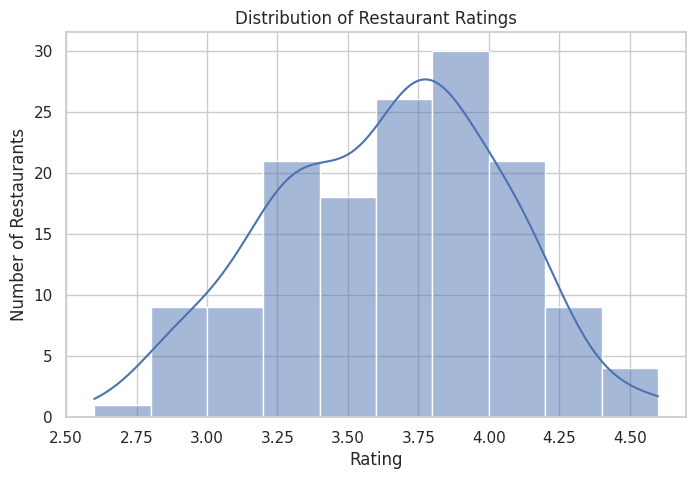

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='rate',
    bins=10,
    kde=True
)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')

plt.show()


In [32]:
print("Minimum rating:", df['rate'].min())
print("Maximum rating:", df['rate'].max())
print("Average rating:", round(df['rate'].mean(), 2))
print("Most common rating:", df['rate'].mode().iloc[0])


Minimum rating: 2.6
Maximum rating: 4.6
Average rating: 3.63
Most common rating: 3.8


Rating Insights

- Ratings in the dataset range from **2.6 to 4.6**.
- The average rating is approximately **3.63**.
- The most frequently occurring rating is **3.8**.

These values are calculated directly from the dataset.

Average Rating by Restaurant Type — Seaborn

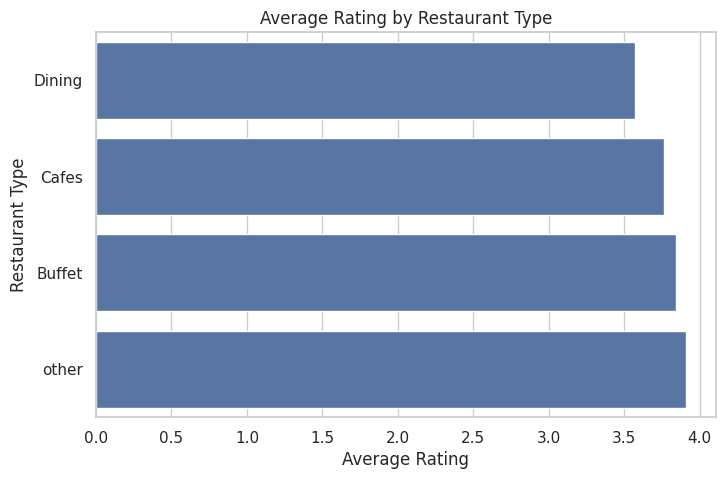

In [33]:
rating_by_type = (
    df.groupby('type_of_restaurant')['rate']
      .mean()
      .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=rating_by_type.values,
    y=rating_by_type.index
)

plt.title('Average Rating by Restaurant Type')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')

plt.show()


Cost Distribution — Seaborn

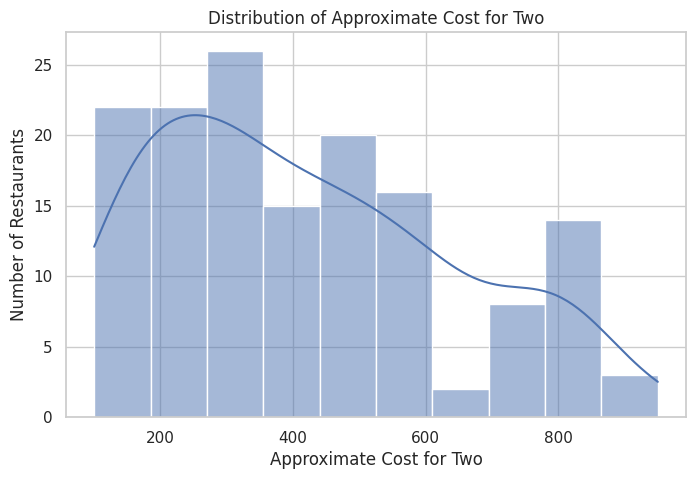

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='cost_for_two',
    bins=10,
    kde=True
)

plt.title('Distribution of Approximate Cost for Two')
plt.xlabel('Approximate Cost for Two')
plt.ylabel('Number of Restaurants')

plt.show()


Cost vs Rating — Seaborn Scatter Plot

This visualization explores whether restaurants with higher approximate costs tend to have higher ratings.

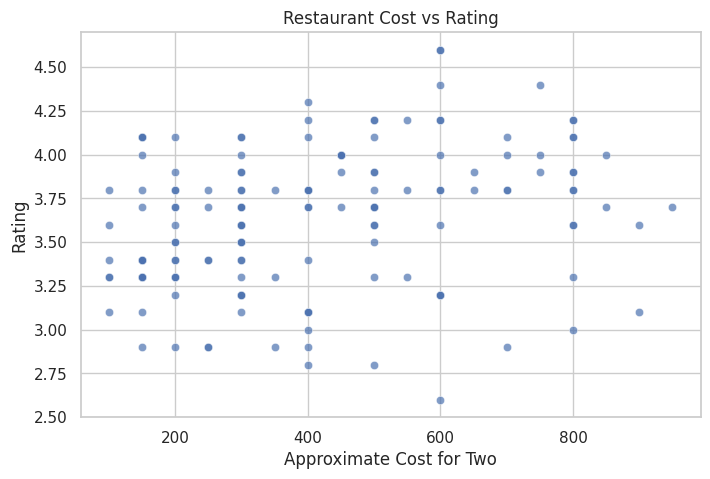

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='cost_for_two',
    y='rate',
    alpha=0.7
)

plt.title('Restaurant Cost vs Rating')
plt.xlabel('Approximate Cost for Two')
plt.ylabel('Rating')

plt.show()


Cost vs Rating — Regression Plot

The regression line summarizes the overall linear trend in the sample.

It represents an association between cost and rating and should not be interpreted as evidence that cost causes changes in rating.

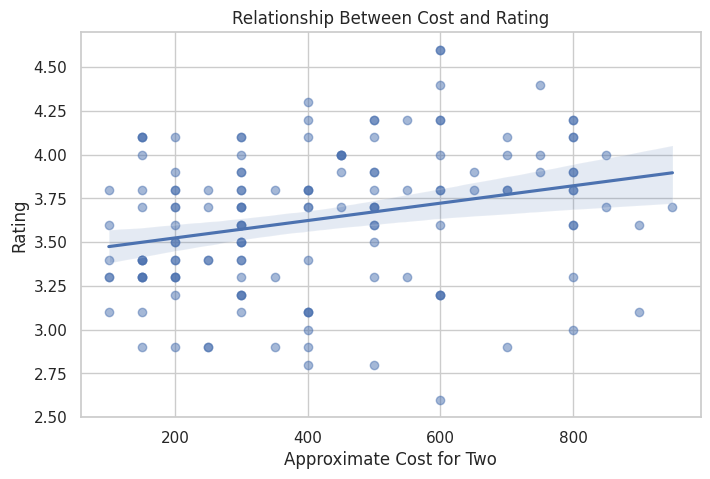

In [36]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='cost_for_two',
    y='rate',
    scatter_kws={'alpha': 0.5}
)

plt.title('Relationship Between Cost and Rating')
plt.xlabel('Approximate Cost for Two')
plt.ylabel('Rating')

plt.show()


Interactive Multivariate Visualization — Plotly

This visualization combines several variables:

- **X-axis:** Approximate cost for two
- **Y-axis:** Rating
- **Bubble size:** Customer votes
- **Color:** Restaurant type
- **Hover information:** Restaurant name

In [37]:
fig = px.scatter(
    df,
    x='cost_for_two',
    y='rate',
    size='votes',
    color='type_of_restaurant',
    hover_name='name',
    title='Restaurant Cost vs Rating',
    labels={
        'cost_for_two': 'Approximate Cost for Two',
        'rate': 'Rating',
        'votes': 'Customer Votes',
        'type_of_restaurant': 'Restaurant Type'
    }
)

fig.show()

Online Ordering Availability — Matplotlib

`Yes` and `No` represent the online-ordering values recorded in the dataset. `No` should not automatically be interpreted as meaning that a restaurant accepts no orders at all.

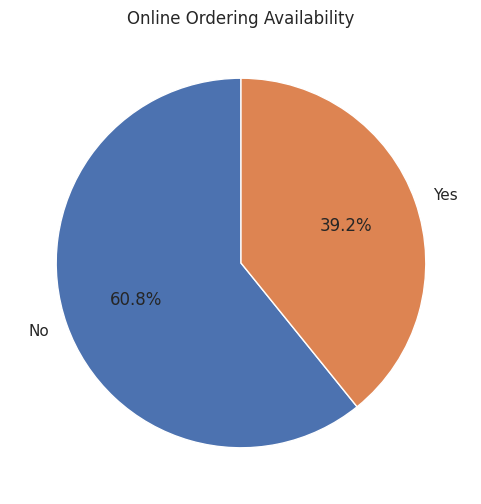

In [38]:
order_counts = df['online_order'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    order_counts.values,
    labels=order_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Online Ordering Availability')
plt.show()

Online Ordering by Restaurant Type — Plotly

In [39]:
order_type = pd.crosstab(
    df['type_of_restaurant'],
    df['online_order']
).reset_index()

fig = px.bar(
    order_type,
    x='type_of_restaurant',
    y=['Yes', 'No'],
    title='Online Ordering Availability by Restaurant Type',
    barmode='group',
    labels={
        'type_of_restaurant': 'Restaurant Type',
        'value': 'Number of Restaurants',
        'variable': 'Online Ordering'
    }
)

fig.show()


Cost Distribution by Restaurant Type — Plotly Box Plot

A box plot compares the median, quartiles, spread, and potential outliers in approximate cost across restaurant categories.

In [40]:
fig = px.box(
    df,
    x='type_of_restaurant',
    y='cost_for_two',
    color='type_of_restaurant',
    points='outliers',
    title='Cost Distribution by Restaurant Type',
    labels={
        'type_of_restaurant': 'Restaurant Type',
        'cost_for_two': 'Approximate Cost for Two'
    }
)

fig.show()


Customer Engagement — Top 10 Restaurants by Votes

Data-quality handling

Some restaurant names appear more than once in the raw dataset. The ranking therefore uses one aggregated value per restaurant name so that repeated rows are not counted as separate restaurants.

In [41]:
top10 = (
    df.groupby('name', as_index=False)['votes']
      .max()
      .nlargest(10, 'votes')
)

top10

,name,votes
41,Empire Restaurant,4884
82,Meghana Foods,4401
92,Onesta,2556
63,Kabab Magic,1720
125,Szechuan Dragon,1647
105,Roving Feast,1047
107,San Churro Cafe,918
53,Gustoes Beer House,868
60,Jeet Restaurant,808
100,Recipe,804


In [42]:
fig = px.bar(
    top10.sort_values('votes'),
    x='votes',
    y='name',
    orientation='h',
    title='Top 10 Restaurants by Customer Votes',
    text='votes',
    labels={
        'votes': 'Customer Votes',
        'name': 'Restaurant'
    }
)

fig.show()

Votes vs Rating — Seaborn

This visualization explores whether restaurants with more customer votes also tend to have higher ratings.

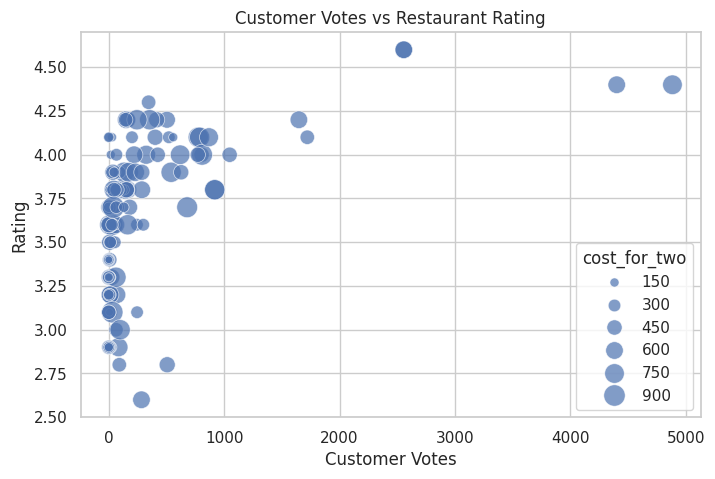

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='votes',
    y='rate',
    size='cost_for_two',
    sizes=(30, 250),
    alpha=0.7
)

plt.title('Customer Votes vs Restaurant Rating')
plt.xlabel('Customer Votes')
plt.ylabel('Rating')

plt.show()


Correlation Analysis

Correlation measures the strength and direction of a linear relationship between numerical variables.

Correlation does not establish causation.

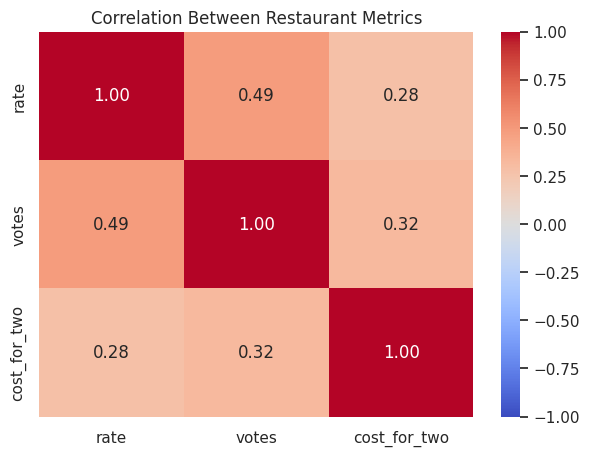

In [44]:
numeric_cols = [
    'rate',
    'votes',
    'cost_for_two'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Restaurant Metrics')

plt.show()


Correlation Values in This Dataset

The approximate correlations are:

- Rating ↔ Votes: **0.49**
- Rating ↔ Cost: **0.28**
- Votes ↔ Cost: **0.32**

All three relationships are positive in this sample. These values describe association, not causation.

Key Findings

Restaurant composition

Dining restaurants account for the largest share of observations in the dataset.

Ratings

Ratings range from 2.6 to 4.6, with an average of approximately 3.63 and a mode of 3.8.

Online ordering

90 restaurants do not provide online ordering in the dataset, while 58 do.

Table booking

Table booking is relatively uncommon in this sample: 8 restaurants provide it and 140 do not.

Customer engagement

Customer votes vary considerably between restaurants. Empire Restaurant and Meghana Foods have the highest vote counts in the dataset.

Relationships

Rating and votes show a moderate positive correlation in this sample, while cost has weaker positive relationships with both rating and votes.

These are descriptive findings from the provided dataset. They should not be treated as causal conclusions or as representative of all restaurants.

Conclusion

This project demonstrates an end-to-end exploratory data analysis and visualization workflow:

Data loading → Cleaning → Validation → EDA → Relationship analysis → Visualization → Interpretation

Libraries demonstrated

- **Pandas:** data cleaning, grouping, aggregation, filtering, and correlation
- **Matplotlib:** foundational static visualizations
- **Seaborn:** statistical and categorical visualizations
- **Plotly:** interactive visualizations

Portfolio takeaway

The value of an exploratory project comes from connecting each visualization to a clear question, interpreting the result carefully, and avoiding conclusions that the data cannot support.